In [39]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

In [40]:
spark = SparkSession.builder \
    .appName("MovieLensProcessing") \
    .master("spark://spark-master:7077") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
    .getOrCreate()

In [41]:
spark

In [42]:
movies_df = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/movies.csv", header=True, inferSchema=True)
ratings_df = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/ratings.csv", header=True, inferSchema=True)

# Display first few rows
movies_df.show(5, truncate=False)
ratings_df.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |17     |4.0   |944249077|
|1     |25     |1.0   |944250228|
|1  

In [43]:
ratings_df = ratings_df.dropna()

In [44]:
user_counts = ratings_df.groupBy("userId").agg(count("rating").alias("rating_count")).filter(col("rating_count") >= 20)
movie_counts = ratings_df.groupBy("movieId").agg(count("rating").alias("rating_count")).filter(col("rating_count") >= 20)

In [45]:
ratings_df = ratings_df.join(user_counts, "userId", "inner").select(ratings_df["*"])
ratings_df = ratings_df.join(movie_counts, "movieId", "inner").select(ratings_df["*"])

In [46]:
ratings_merged = ratings_df.join(movies_df, "movieId", "left")

In [47]:
ratings_df.show(5, truncate=False)
print("Shape of cleaned ratings:", (ratings_df.count(), len(ratings_df.columns)))
print("Unique users:", ratings_df.select("userId").distinct().count())
print("Unique movies:", ratings_df.select("movieId").distinct().count())

+------+-------+------+----------+
|userId|movieId|rating|timestamp |
+------+-------+------+----------+
|148   |1      |1.0   |1471747611|
|148   |2      |2.5   |1471833148|
|148   |10     |4.0   |1471832439|
|148   |47     |3.5   |1471833650|
|148   |50     |4.0   |1471747003|
+------+-------+------+----------+
only showing top 5 rows

Shape of cleaned ratings: (31725920, 4)
Unique users: 200948
Unique movies: 23350


In [48]:
user_avg = ratings_df.groupBy("userId").agg(avg("rating").alias("rating_avg"))
ratings_df = ratings_df.join(user_avg, "userId")
ratings_df = ratings_df.withColumn("rating_centered", col("rating") - col("rating_avg"))

In [49]:
ratings_df.select("userId", "movieId", "rating", "rating_avg", "rating_centered").show(5, truncate=False)

+------+-------+------+-----------------+-------------------+
|userId|movieId|rating|rating_avg       |rating_centered    |
+------+-------+------+-----------------+-------------------+
|148   |1088   |0.5   |2.169207317073171|-1.669207317073171 |
|148   |2366   |1.0   |2.169207317073171|-1.169207317073171 |
|148   |4519   |1.0   |2.169207317073171|-1.169207317073171 |
|496   |1580   |3.5   |4.283333333333333|-0.7833333333333332|
|833   |1580   |2.5   |3.436685288640596|-0.9366852886405961|
+------+-------+------+-----------------+-------------------+
only showing top 5 rows



In [50]:
train_df, test_df = ratings_df.randomSplit([0.8, 0.2], seed=42)

In [51]:
train_df.select("userId", "movieId", "rating").write.csv("hdfs://namenode:9000/user/rawan/movielens/als_train_spark.csv", header=True, mode="overwrite")
test_df.select("userId", "movieId", "rating").write.csv("hdfs://namenode:9000/user/rawan/movielens/als_test_spark.csv", header=True, mode="overwrite")

In [52]:
train_df_check = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/als_train_spark.csv", header=True, inferSchema=True)
test_df_check = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/als_test_spark.csv", header=True, inferSchema=True)
print("Training set shape:", (train_df_check.count(), len(train_df_check.columns)))
print("Test set shape:", (test_df_check.count(), len(test_df_check.columns)))
train_df_check.show(5, truncate=False)
test_df_check.show(5, truncate=False)

Training set shape: (25379611, 3)
Test set shape: (6346309, 3)
+------+-------+------+
|userId|movieId|rating|
+------+-------+------+
|12    |261    |3.0   |
|12    |356    |3.0   |
|12    |661    |2.0   |
|12    |724    |4.5   |
|12    |1285   |3.0   |
+------+-------+------+
only showing top 5 rows

+------+-------+------+
|userId|movieId|rating|
+------+-------+------+
|12    |31     |3.0   |
|12    |783    |3.0   |
|12    |1022   |3.0   |
|12    |1888   |4.5   |
|12    |2605   |3.0   |
+------+-------+------+
only showing top 5 rows



In [53]:
train_df = train_df.withColumn("userId", col("userId").cast(IntegerType())) \
                   .withColumn("movieId", col("movieId").cast(IntegerType()))
train_df.select("userId", "movieId", "rating").write.csv("hdfs://namenode:9000/user/rawan/movielens/als_input_spark.csv", header=True, mode="overwrite")

In [54]:
als_input_df = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/als_input_spark.csv", header=True, inferSchema=True)
print("ALS Input Shape:", (als_input_df.count(), len(als_input_df.columns)))
als_input_df.show(5, truncate=False)

ALS Input Shape: (25379611, 3)
+------+-------+------+
|userId|movieId|rating|
+------+-------+------+
|12    |261    |3.0   |
|12    |356    |3.0   |
|12    |661    |2.0   |
|12    |724    |4.5   |
|12    |1285   |3.0   |
+------+-------+------+
only showing top 5 rows



In [55]:
als = ALS(maxIter=10, regParam=0.1, userCol="userId", itemCol="movieId", ratingCol="rating", 
          coldStartStrategy="drop", nonnegative=True, seed=42)
model = als.fit(train_df)

In [56]:
predictions = model.transform(test_df)

In [57]:
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print(f"Root Mean Square Error (RMSE) on test data: {rmse}")

Root Mean Square Error (RMSE) on test data: 0.8103786361674283


In [58]:
user_recs = model.recommendForUserSubset(test_df.filter(col("userId") == 1), 10)
user_recs.show(truncate=False)

+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                                          |
+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1     |[{86237, 4.5513806}, {88570, 4.383154}, {153909, 4.3277545}, {179297, 4.309379}, {171991, 4.2649736}, {51559, 4.251936}, {26756, 4.2371254}, {164643, 4.187876}, {197041, 4.183629}, {133333, 4.1798115}]|
+------+----------------------------------------------------------------------------------------------------------------------------------------------------

In [59]:
ratings_hist = ratings_df.groupBy("rating").agg(count("rating").alias("count")).orderBy("rating")
ratings_hist_pd = ratings_hist.toPandas()

In [60]:
print("Ratings Histogram Data:")
print(ratings_hist_pd)

Ratings Histogram Data:
   rating    count
0     0.5   507927
1     1.0   933549
2     1.5   519243
3     2.0  2004854
4     2.5  1653404
5     3.0  5997914
6     3.5  4240810
7     4.0  8329117
8     4.5  2960463
9     5.0  4578639


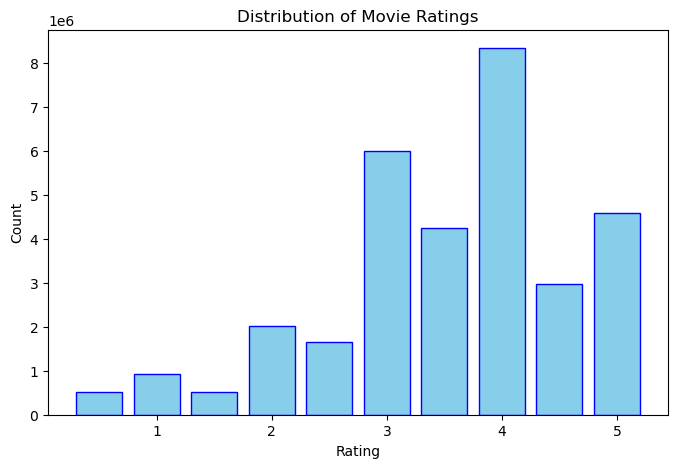

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(ratings_hist_pd['rating'], ratings_hist_pd['count'], width=0.4, color='skyblue', edgecolor='blue')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [62]:
from pyspark.sql.functions import col, count, avg, explode, split
import pandas as pd

In [64]:
movie_ratings = ratings_df.groupBy("movieId").agg(avg("rating").alias("avg_rating"), count("rating").alias("rating_count")) \
                         .filter(col("rating_count") >= 100) \
                         .join(movies_df, "movieId", "left") \
                         .select("movieId", "title", "avg_rating", "rating_count") \
                         .orderBy(col("avg_rating").desc()).limit(10)
top_movies_pd = movie_ratings.toPandas()
print("Top 10 Movies by Average Rating:")
print(top_movies_pd)

Top 10 Movies by Average Rating:
   movieId                             title  avg_rating  rating_count
0   171011            Planet Earth II (2016)    4.446830          1956
1   159817               Planet Earth (2006)    4.444369          2948
2   170705           Band of Brothers (2001)    4.426539          2811
3      318  Shawshank Redemption, The (1994)    4.404614        102929
4   171495                            Cosmos    4.330081           615
5      858             Godfather, The (1972)    4.317030         66440
6   202439                   Parasite (2019)    4.312254         11670
7   179135             Blue Planet II (2017)    4.300086          1163
8   198185                 Twin Peaks (1989)    4.298684          1140
9   220528           Twelve Angry Men (1954)    4.286192           449


In [65]:
movies_with_genres = movies_df.withColumn("genre", explode(split(col("genres"), "\\|")))
genre_ratings = ratings_df.join(movies_with_genres, "movieId", "left") \
                         .groupBy("genre").agg(count("rating").alias("rating_count")) \
                         .orderBy(col("rating_count").desc())
genre_ratings_pd = genre_ratings.toPandas()
print("Genre Popularity Data:")
print(genre_ratings_pd)

Genre Popularity Data:
                 genre  rating_count
0                Drama      13865970
1               Comedy      11135697
2               Action       9635828
3             Thriller       8643438
4            Adventure       7575808
5               Sci-Fi       5701783
6              Romance       5492692
7                Crime       5352728
8              Fantasy       3690531
9             Children       2717791
10             Mystery       2603218
11              Horror       2462938
12           Animation       2197103
13                 War       1587302
14                IMAX       1494079
15             Musical       1156885
16             Western        592286
17         Documentary        396222
18           Film-Noir        303599
19  (no genres listed)         35945


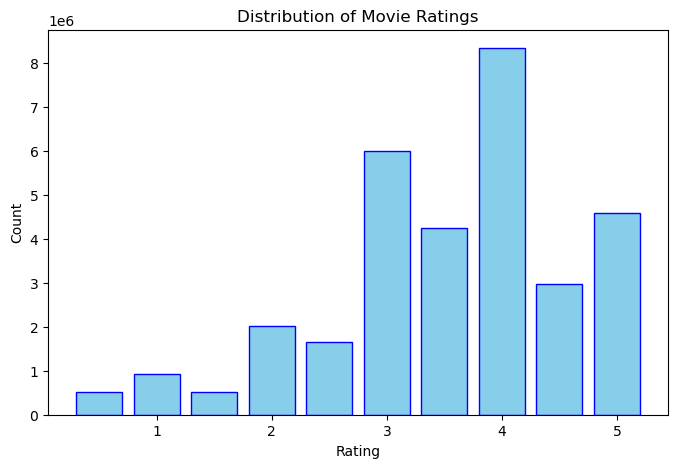

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(ratings_hist_pd['rating'], ratings_hist_pd['count'], width=0.4, color='skyblue', edgecolor='blue')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

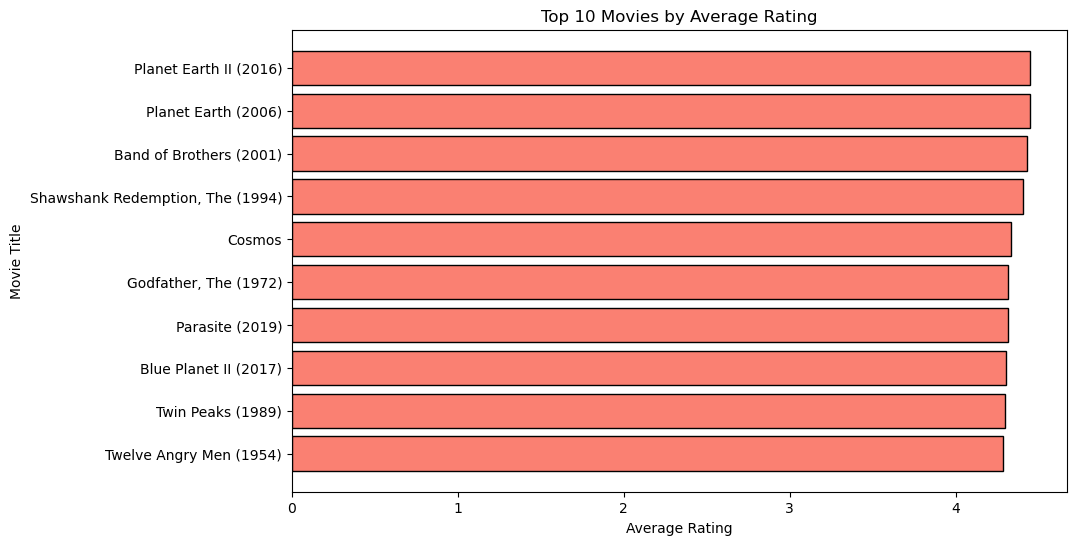

In [69]:
plt.figure(figsize=(10, 6))
plt.barh(top_movies_pd['title'], top_movies_pd['avg_rating'], color='salmon', edgecolor='black')
plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.gca().invert_yaxis()
plt.show()

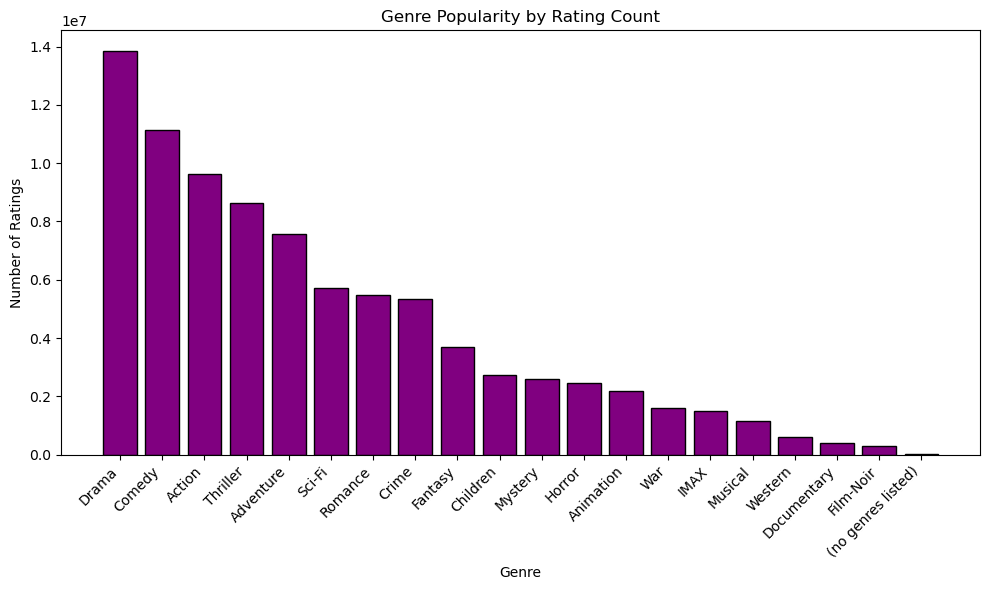

In [70]:
plt.figure(figsize=(10, 6))
plt.bar(genre_ratings_pd['genre'], genre_ratings_pd['rating_count'], color='purple', edgecolor='black')
plt.title("Genre Popularity by Rating Count")
plt.xlabel("Genre")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [72]:
import time

In [73]:
start_time = time.time()
movies_df = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/movies.csv", header=True, inferSchema=True)
ratings_df = spark.read.csv("hdfs://namenode:9000/user/rawan/movielens/ratings.csv", header=True, inferSchema=True)
data_load_time = time.time() - start_time
print(f"Data loading time: {data_load_time:.2f} seconds")

Data loading time: 19.33 seconds


In [74]:
start_time = time.time()
ratings_df = ratings_df.dropna()
user_counts = ratings_df.groupBy("userId").agg(count("rating").alias("rating_count")).filter(col("rating_count") >= 20)
movie_counts = ratings_df.groupBy("movieId").agg(count("rating").alias("rating_count")).filter(col("rating_count") >= 20)
ratings_df = ratings_df.join(user_counts, "userId", "inner").select(ratings_df["*"])
ratings_df = ratings_df.join(movie_counts, "movieId", "inner").select(ratings_df["*"])
preprocessing_time = time.time() - start_time
print(f"Preprocessing time: {preprocessing_time:.2f} seconds")

Preprocessing time: 0.09 seconds


In [75]:
start_time = time.time()
als = ALS(maxIter=10, regParam=0.1, userCol="userId", itemCol="movieId", ratingCol="rating", 
          coldStartStrategy="drop", nonnegative=True, seed=42)
model = als.fit(train_df)
training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

Training time: 258.71 seconds


In [76]:
start_time = time.time()
predictions = model.transform(test_df)
prediction_time = time.time() - start_time
print(f"Prediction time: {prediction_time:.2f} seconds")

Prediction time: 0.05 seconds


In [77]:
total_time = data_load_time + preprocessing_time + training_time + prediction_time
print(f"Total execution time: {total_time:.2f} seconds")

Total execution time: 278.18 seconds


In [78]:
evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
rmse = evaluator.evaluate(predictions)
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")

Root Mean Square Error (RMSE): 0.8104
